<a href="https://colab.research.google.com/github/pxs1990/NLP_LLM/blob/main/RAG_Q/A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **RAG ==> LLM generates the answer based on retrieved external knowledge.**

# **RAG workflow:**

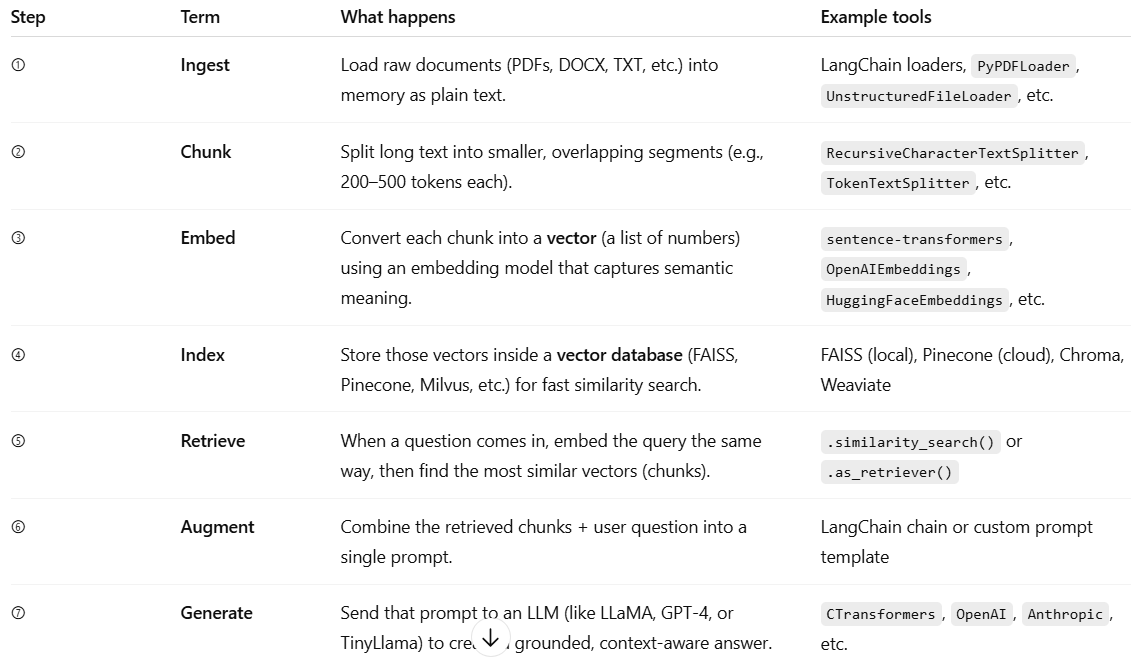



In [3]:
!pip install faiss-cpu

In [4]:
# Install the right packages
!pip uninstall -y langchain-classic langchain langchain-core langchain-community langchain-text-splitters

Found existing installation: langchain 0.3.27
Uninstalling langchain-0.3.27:
  Successfully uninstalled langchain-0.3.27
Found existing installation: langchain-core 0.3.79
Uninstalling langchain-core-0.3.79:
  Successfully uninstalled langchain-core-0.3.79
Found existing installation: langchain-community 0.3.27
Uninstalling langchain-community-0.3.27:
  Successfully uninstalled langchain-community-0.3.27
Found existing installation: langchain-text-splitters 0.3.11
Uninstalling langchain-text-splitters-0.3.11:
  Successfully uninstalled langchain-text-splitters-0.3.11


In [5]:
!pip install -q \
  "requests==2.32.4" \
  "langchain-core>=0.3.72,<1.0.0" \
  "langchain-community>=0.3.9,<0.4.0" \
  "langchain-text-splitters>=0.3.9,<1.0.0" \
  pypdf faiss-cpu transformers accelerate sentencepiece

In [6]:
# Correct imports
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.docstore import InMemoryDocstore
from langchain_community.docstore.document import Document

In [7]:
import os, json, torch, faiss, numpy as np
from typing import List, Tuple
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM

In [8]:
# 1) CONFIG
PDF_PATH = "/content/Resume_Pushpa_Shrestha.pdf"
TOP_K = 5

# --- LLaMA (decoder) choices
# LLM_ID = "meta-llama/Meta-Llama-3.1-8B-Instruct"     # gated; needs access
# LLM_ID = "meta-llama/Meta-Llama-3-8B-Instruct"      # gated; alt
LLM_ID = "NousResearch/Hermes-3-Llama-3.1-8B"       # community instruct (often easier)
# LLM_ID = "unsloth/llama-3-8b-Instruct"              # variant; check availability

DTYPE = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8 else torch.float16
DEVICE_MAP = "auto"

In [9]:
# 2) EMBEDDINGS (MiniLM encoder)

EMB_ID = "sentence-transformers/all-MiniLM-L6-v2"
emb_tok = AutoTokenizer.from_pretrained(EMB_ID)
emb_model = AutoModel.from_pretrained(EMB_ID)
emb_model.eval()

@torch.no_grad()
def embed_texts(texts: List[str]) -> np.ndarray:
    """Mean-pool MiniLM outputs with mask; L2-normalize for cosine/IP search."""
    batch = emb_tok(texts, return_tensors="pt", padding=True, truncation=True)
    outputs = emb_model(**batch)
    last_hidden = outputs.last_hidden_state            # [B, T, H]
    mask = batch["attention_mask"].unsqueeze(-1)       # [B, T, 1]
    summed = (last_hidden * mask).sum(dim=1)           # [B, H]
    counts = mask.sum(dim=1).clamp(min=1)              # [B, 1]
    embs = (summed / counts).cpu().numpy()             # [B, H]
    embs = embs / (np.linalg.norm(embs, axis=1, keepdims=True) + 1e-12)
    return embs.astype("float32")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [10]:
# 3) LLaMA (decoder) for generation
gen_tok = AutoTokenizer.from_pretrained(LLM_ID, use_fast=True)
gen_model = AutoModelForCausalLM.from_pretrained(
    LLM_ID,
    torch_dtype=DTYPE,
    device_map=DEVICE_MAP
)

def llama_generate(system_prompt: str, user_prompt: str,
                   max_new_tokens: int = 256, temperature: float = 0.2) -> str:
    """Use chat template when available (LLaMA-3 supports it)."""
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user",   "content": user_prompt},
    ]
    # If tokenizer has a chat template, use it; otherwise, fall back to plain concat
    if hasattr(gen_tok, "apply_chat_template") and gen_tok.chat_template:
        prompt = gen_tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = gen_tok(prompt, return_tensors="pt").to(gen_model.device)
    else:
        concat = f"{system_prompt}\n\n{user_prompt}"
        inputs = gen_tok(concat, return_tensors="pt").to(gen_model.device)

    with torch.no_grad():
        output_ids = gen_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=True if temperature > 0 else False,
            pad_token_id=gen_tok.eos_token_id
        )
    text = gen_tok.decode(output_ids[0], skip_special_tokens=True)
    # Try to strip the prompt if it appears in the decode:
    return text.split(user_prompt)[-1].strip()

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [11]:
# 4) Load PDF → pages → chunks
pdf_loader = PyPDFLoader(PDF_PATH)
raw_docs: List[Document] = pdf_loader.load()  # list of Docs/pages, 1 Doc = 1 page

splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=150)
chunks: List[Document] = splitter.split_documents(raw_docs) # list of smaller Docs with 800 char text chunk

In [12]:
for i, chunk in enumerate(chunks):
    if i<2:
        print(f"🔹 Chunk {i}")
        print(f"Page: {chunk.metadata.get('page', 'N/A')}")
        print(f"Text:\n{chunk.page_content[:400]}")  # print first 400 chars for readability
        print("-" * 80)
    else:
        break

🔹 Chunk 0
Page: 0
Text:
Dr. Pushpa Shrestha 
Data Scientist 
pshrestha0125@gmail.com | 4697086743 || Hurst TX 76112 
LinkedIn: https://www.linkedin.com/in/pushpa-shrestha01/ 
 
PROFESSIONAL SUMMARY: 
I am a results -driven Data Scientist with over five years of experience turning complex data 
into practical business impact. My work spans predictive and descriptive analytics, statistical 
modeling, machine learning, deep
--------------------------------------------------------------------------------
🔹 Chunk 1
Page: 0
Text:
faster, data-informed decisions. I combine hands-on technical expertise with a strategic mindset, 
designing and fine -tuning models, translating findings into clear insights, and deploying 
scalable AI systems on cloud platforms. Skilled in Python, scikit -learn, PyTorch, and 
Transformers, I  am passionate about using data to solve real -world problems, streamline 
operations, and deliver measur
---------------------------------------------------------------------

In [13]:
# 5) FAISS(fb ai sim search) index + docstore

texts = [doc.page_content for doc in chunks]
vecs = embed_texts(texts)

dim = vecs.shape[1]

index = faiss.IndexFlatIP(dim)          # cosine via inner product on normalized vectors
docstore = InMemoryDocstore()
index_to_doc: dict[int, str] = {}



for i, (doc, v) in enumerate(zip(chunks, vecs)):
    index.add(v[np.newaxis, :])         # add single vector
    key = f"doc-{i}"
    docstore.add({key: doc})
    index_to_doc[i] = key

In [14]:
# 6) Retrieval

def retrieve(query: str, k: int = TOP_K) -> List[Tuple[Document, float, int]]:
    qv = embed_texts([query])           # [1, dim]
    D, I = index.search(qv, k)          # distances (similarities), indices
    out = []
    for score, idx in zip(D[0], I[0]):
        if idx == -1:
            continue
        key = index_to_doc.get(int(idx))
        if not key:
            continue
        doc = docstore.search(key)
        out.append((doc, float(score), int(idx)))
    return out

In [15]:
# 7) RAG answer (grounded)

def rag_answer(question: str, k: int = TOP_K, return_sources: bool = True) -> dict:
    hits = retrieve(question, k=k)
    context = "\n\n".join([h[0].page_content for h in hits])

    sys = ("You are an assistant that answers STRICTLY from the provided résumé context. "
           "If the answer is not present, say exactly: 'I cannot find that in the résumé.'")
    user = f"Résumé context:\n{context}\n\nQuestion: {question}\nAnswer concisely:"

    answer = llama_generate(sys, user, max_new_tokens=256, temperature=0.2)

    result = {"answer": answer}
    if return_sources:
        result["sources"] = [
            {
                "score": round(h[1], 4),
                "meta": h[0].metadata,
                "preview": h[0].page_content[:240].replace("\n", " ") + ("..." if len(h[0].page_content) > 240 else "")
            } for h in hits
        ]
    return result

In [16]:
# 8) Quick tries you mentioned

for q in [
    "List my key skills.",
    "How many total years of experience do I have?",
    "What is my highest level of education and in what field?",
    "Where am I based?",
    "What is my age?"
]:
    result = rag_answer(q, k=5, return_sources=True)
    print(f"\nQ: {q}\nA: {result['answer']}")
    # Uncomment to inspect sources:
    # for s in out["sources"]:
    #     print("  •", s)



Q: List my key skills.
A: <|im_start|>assistant
- Python
- SQL
- R
- Java
- C
- C++
- JavaScript
- HTML
- CSS
- NumPy
- Pandas
- scikit-learn
- PyTorch
- Transformers (Hugging Face)
- LangChain
- Seaborn
- Matplotlib
- nltk
- spacy
- TensorFlow
- Keras
- Regression (Linear/Logistic)
- Classification
- Clustering (K-Modeling, Regression Analysis, Decision Trees, Ensemble Methods, KNN, K-Means)
- Advanced Machine Learning
- Master Data Analysis
- Cost-effective Automation
- Feature Engineering
- Data Pipelines
- Database Management
- Data Mining
- Logistic Regression

Q: How many total years of experience do I have?
A: <|im_start|>system
You are an assistant that answers STRICTLY from the provided résumé context. If the answer is not present, say exactly: 'I cannot find that in the résumé.'
<|im_start|>user
Résumé context:
CAREER EXPERIENCE:  
USAA || Remote                     May 2025 - Present 
Data Scientist 
Responsibilities: 
● Fine-tuned large language models (LLMs) such as Llama